In [47]:
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv("titanic.csv")
df

,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S
2,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S
3,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S
4,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...,...
1304,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C
1305,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C
1307,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C


In [49]:
survived = df["survived"].sum()

In [50]:
dead = (df["survived"] == 0).sum()
dead

np.int64(809)

In [51]:
# Predict 0
# Total correct / total
dead / (dead + survived)

np.float64(0.6180290297937356)

In [52]:
df

,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S
2,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S
3,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S
4,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...,...
1304,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C
1305,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C
1307,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C


In [53]:
titanic_feature = ["sex", "age", "sibsp", "parch", "fare"]
X = df[titanic_feature]

In [54]:
X

,sex,age,sibsp,parch,fare
0,female,29.0000,0,0,211.3375
1,male,0.9167,1,2,151.5500
2,female,2.0000,1,2,151.5500
3,male,30.0000,1,2,151.5500
4,female,25.0000,1,2,151.5500
...,...,...,...,...,...
1304,female,14.5000,1,0,14.4542
1305,female,NaN,1,0,14.4542
1306,male,26.5000,0,0,7.2250
1307,male,27.0000,0,0,7.2250


In [55]:
X = pd.get_dummies(X, drop_first=True)

In [56]:
X

,age,sibsp,parch,fare,sex_male
0,29.0000,0,0,211.3375,False
1,0.9167,1,2,151.5500,True
2,2.0000,1,2,151.5500,False
3,30.0000,1,2,151.5500,True
4,25.0000,1,2,151.5500,False
...,...,...,...,...,...
1304,14.5000,1,0,14.4542,False
1305,NaN,1,0,14.4542,False
1306,26.5000,0,0,7.2250,True
1307,27.0000,0,0,7.2250,True


In [57]:
X.isna().sum()

age         263
sibsp         0
parch         0
fare          1
sex_male      0
dtype: int64

In [58]:
X["age"] = X["age"].fillna(X["age"].mean())

In [59]:
X.isna().sum()

age         0
sibsp       0
parch       0
fare        1
sex_male    0
dtype: int64

In [60]:
X["fare"] = X["fare"].ffill()

In [61]:
X.isna().sum()

age         0
sibsp       0
parch       0
fare        0
sex_male    0
dtype: int64

In [62]:
X.describe()

,age,sibsp,parch,fare
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,29.881135,0.498854,0.385027,33.276193
std,12.883199,1.041658,0.865560,51.743584
min,0.166700,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.895800
50%,29.881135,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.275000
max,80.000000,8.000000,9.000000,512.329200


In [63]:
y = df["survived"]

In [64]:
all_data = pd.concat([y, X], axis=1)

In [65]:
all_data

,survived,age,sibsp,parch,fare,sex_male
0,1,29.000000,0,0,211.3375,False
1,1,0.916700,1,2,151.5500,True
2,0,2.000000,1,2,151.5500,False
3,0,30.000000,1,2,151.5500,True
4,0,25.000000,1,2,151.5500,False
...,...,...,...,...,...,...
1304,0,14.500000,1,0,14.4542,False
1305,0,29.881135,1,0,14.4542,False
1306,0,26.500000,0,0,7.2250,True
1307,0,27.000000,0,0,7.2250,True


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [67]:
data_train, data_test = train_test_split(all_data, test_size=0.2, random_state=32)

In [68]:
X_train = data_train.drop("survived", axis=1)
y_train = data_train["survived"]
X_test = data_test.drop("survived", axis=1)
y_test = data_test["survived"]

In [69]:
LR = LogisticRegression()

In [70]:
LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
y_pred = LR.predict(X_test)

In [72]:
classification_report?

Signature:
classification_report(
    y_true,
    y_pred,
    *,
    labels=None,
    target_names=None,
    sample_weight=None,
    digits=2,
    output_dict=False,
    zero_division='warn',
)
Docstring:
Build a text report showing the main classification metrics.

Read more in the :ref:`User Guide <classification_report>`.

Parameters
----------
y_true : 1d array-like, or label indicator array / sparse matrix
    Ground truth (correct) target values. Sparse matrix is only supported when
    targets are of :term:`multilabel` type.

y_pred : 1d array-like, or label indicator array / sparse matrix
    Estimated targets as returned by a classifier. Sparse matrix is only
    supported when targets are of :term:`multilabel` type.

labels : array-like of shape (n_labels,), default=None
    Optional list of label indices to include in the report.

target_names : array-like of shape (n_labels,), default=None
    Optional display names matching the labels (same order).

sample_weight : array-l

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       145
           1       0.78      0.66      0.71       117

    accuracy                           0.76       262
   macro avg       0.77      0.75      0.76       262
weighted avg       0.76      0.76      0.76       262



In [74]:
cm = confusion_matrix(y_test, y_pred)

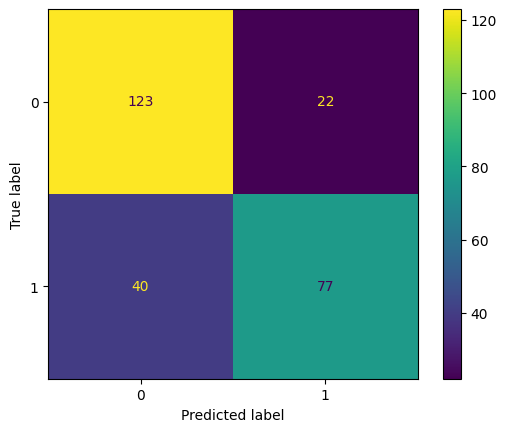

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay(cm).plot()

In [76]:
cross_val_score?

Signature:
cross_val_score(
    estimator,
    X,
    y=None,
    *,
    groups=None,
    scoring=None,
    cv=None,
    n_jobs=None,
    verbose=0,
    params=None,
    pre_dispatch='2*n_jobs',
    error_score=nan,
)
Docstring:
Evaluate a score by cross-validation.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
estimator : estimator object implementing 'fit'
    The object to use to fit the data.

X : {array-like, sparse matrix} of shape (n_samples, n_features)
    The data to fit. Can be for example a list, or an array.

y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
    The target variable to try to predict in the case of
    supervised learning.

groups : array-like of shape (n_samples,), default=None
    Group labels for the samples used while splitting the dataset into
    train/test set. Only used in conjunction with a "Group" :term:`cv`
    instance (e.g., :class:`GroupKFold`).

    .. versionchanged:: 1.

In [77]:
precision = cross_val_score(LR, X, y=y, cv=10)
precision

array([0.80152672, 0.77862595, 0.85496183, 0.79389313, 0.80152672,
       0.79389313, 0.72519084, 0.6870229 , 0.73282443, 0.76923077])

In [78]:
precision.mean() # isolated "1" as 1 when it truely was 1

np.float64(0.7738696418085731)

In [79]:
import seaborn as sns

<Axes: >

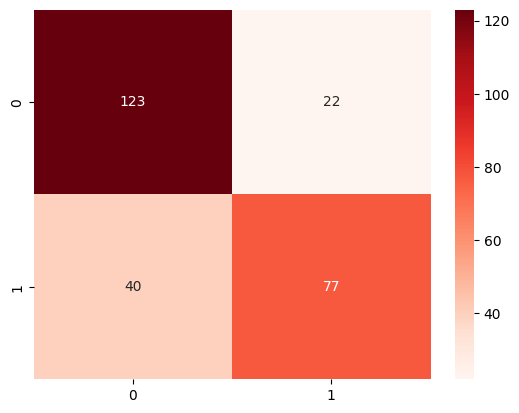

In [80]:
sns.heatmap(cm, annot=True, cmap="Reds", fmt="d")

In [81]:
titanic_feature

['sex', 'age', 'sibsp', 'parch', 'fare']

In [82]:
new_passenger = [[False, 100, 3, 50, 50]]

In [83]:
LR.predict(new_passenger)

c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [84]:
from sklearn.metrics import balanced_accuracy_score

In [85]:
print(balanced_accuracy_score(y_test, y_pred))

0.7531977600943118


In [86]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

           0       0.78      0.83      0.80       145
           1       0.77      0.70      0.74       117

    accuracy                           0.77       262
   macro avg       0.77      0.77      0.77       262
weighted avg       0.77      0.77      0.77       262



0.7676687297376952

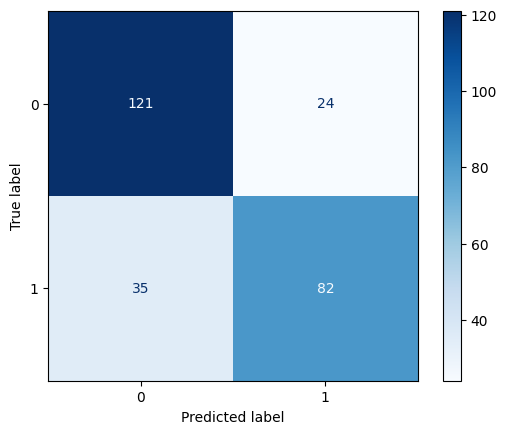

In [87]:
dt = DecisionTreeClassifier(random_state=32)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
print(classification_report(y_test, y_pred))
balanced_accuracy_score(y_test, y_pred)

In [88]:
from sklearn.tree import plot_tree

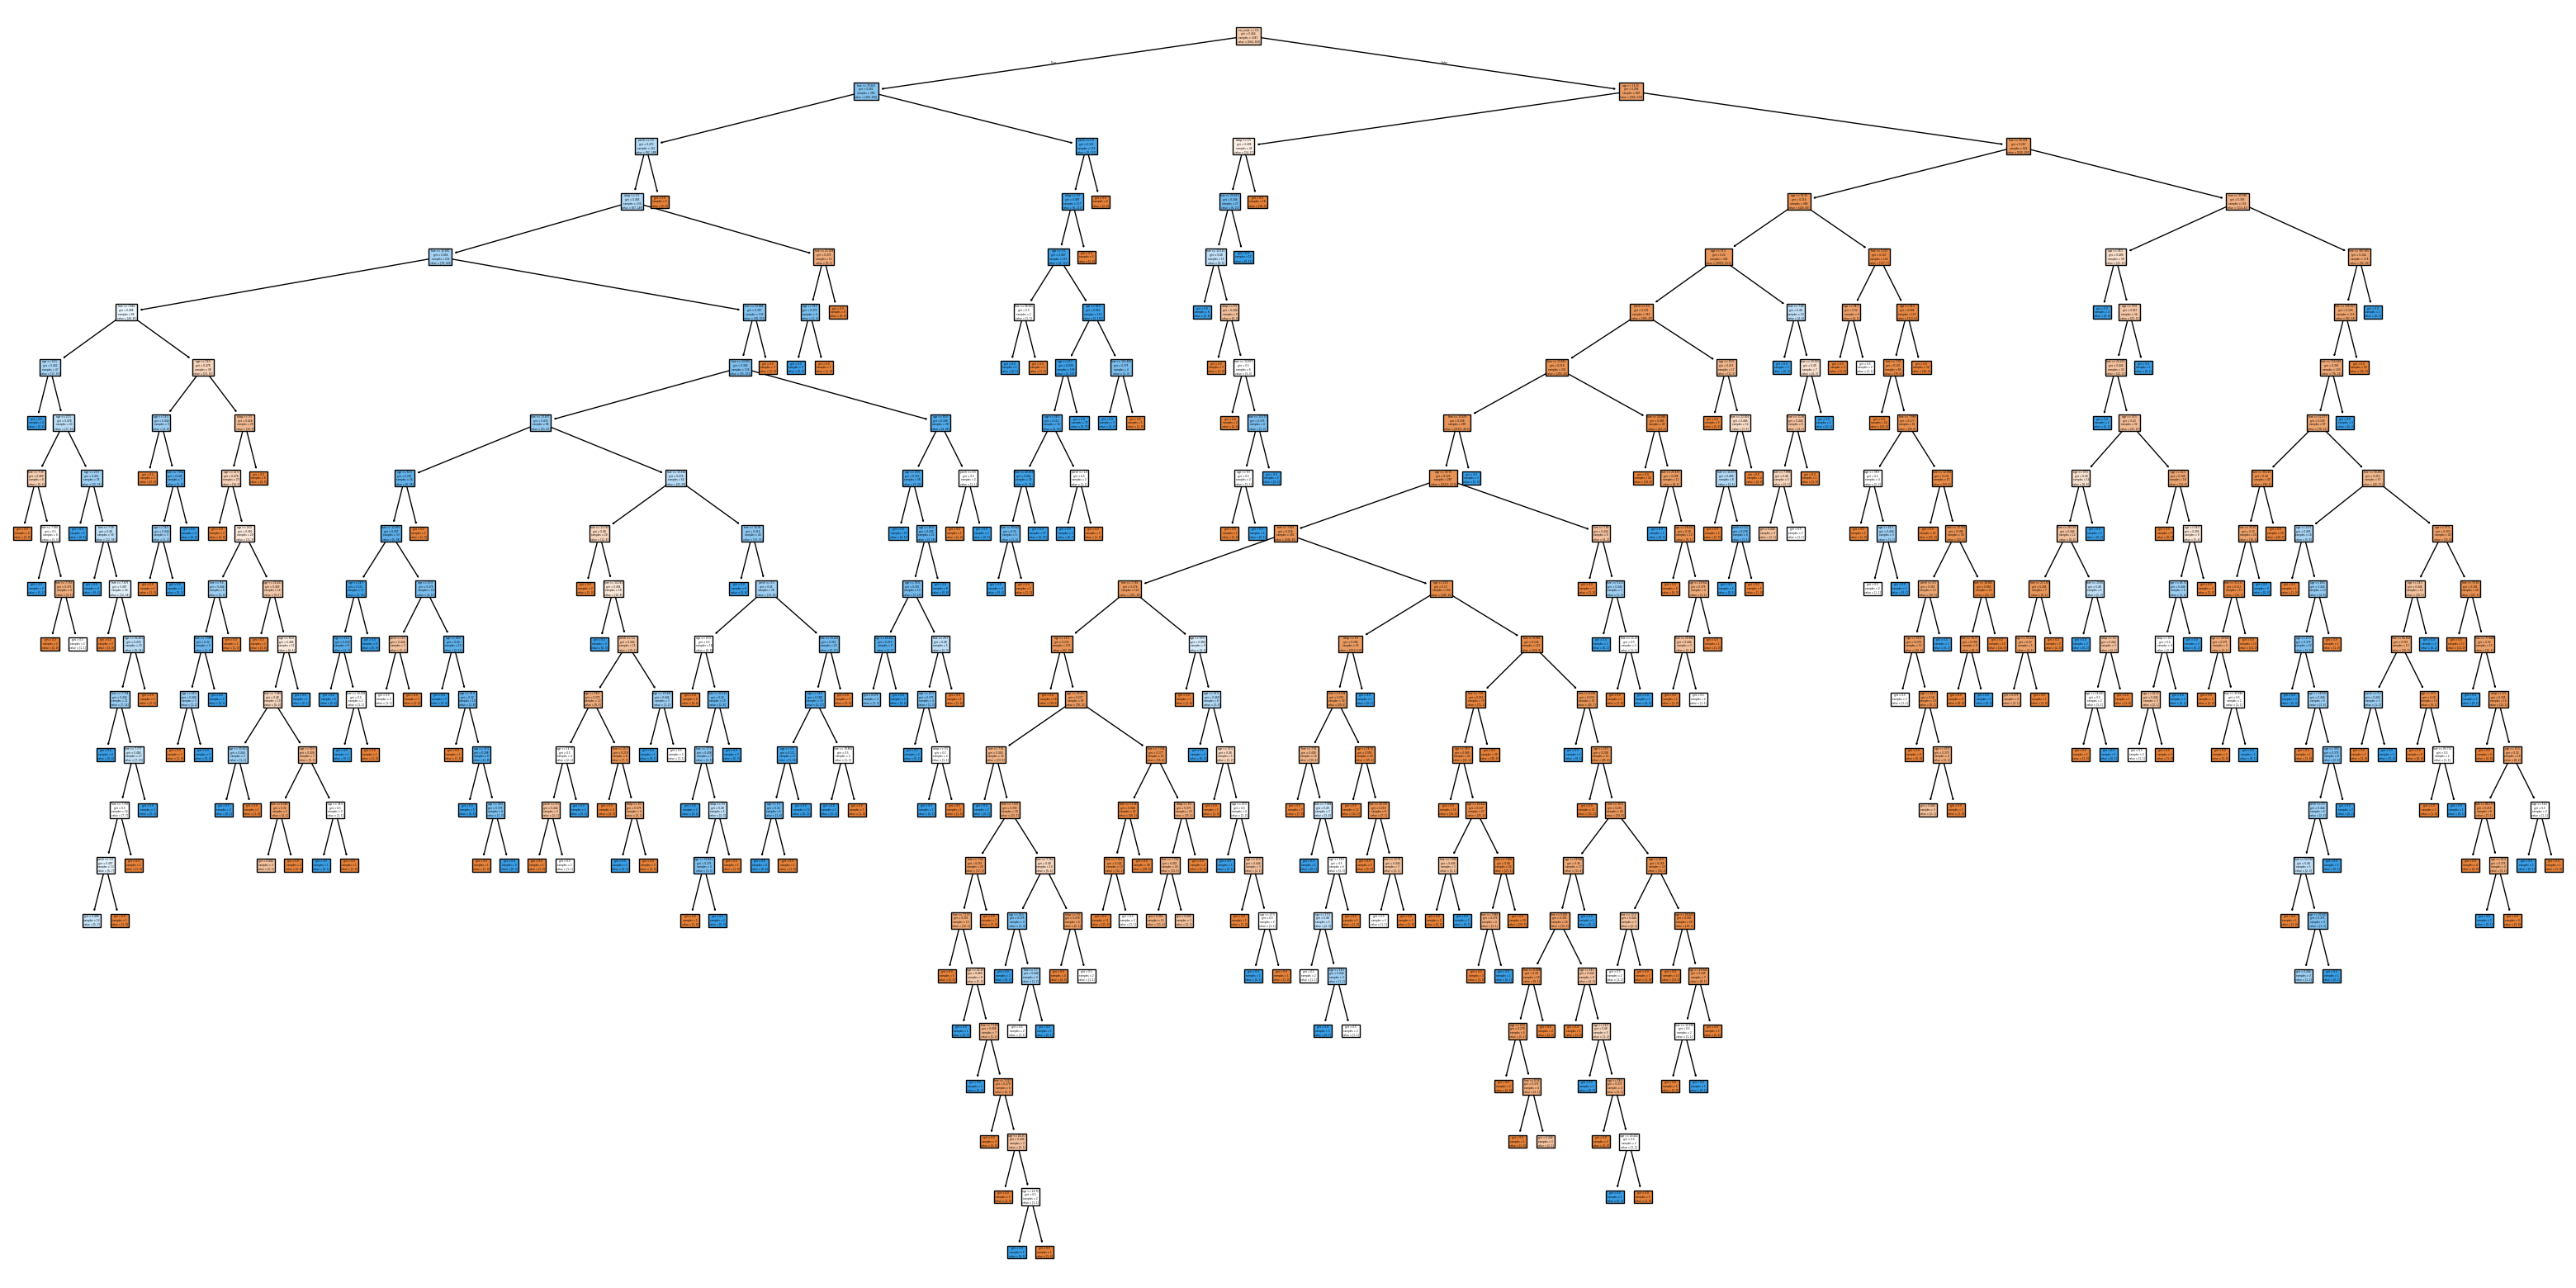

In [89]:
plt.figure(figsize=(40, 20))
plot_tree(dt, feature_names=list(X.columns), filled=True)
plt.show()

In [90]:
from supertree import SuperTree

In [91]:
super_tree = SuperTree(
    dt,
    X_train.values,
    y_train.values,
    list(X_train.columns),
    ["NO SURVIVED", "SURVIVED"]
)

super_tree.show_tree()

In [92]:
importances = pd.DataFrame({'feature': X_train.columns, 'importance': dt.feature_importances_})
importances
importances

,feature,importance
0,age,0.228314
1,sibsp,0.066916
2,parch,0.041291
3,fare,0.351008
4,sex_male,0.312472
